# Home Credit Default Risk: Baselines and Hyperparameter Tuning

Notebook 3 of 5. Using training rows only, it sets two baselines, drops features that carry no information, and tunes LightGBM and XGBoost with Optuna. Final training happens in notebook 4, so a problem there never costs these tuning hours.

Tuning runs at learning rate 0.1 to keep each trial short on Kaggle's 4 CPU cores; notebook 4 retrains with the tuned tree settings at learning rate 0.02. XGBoost is tuned on a stratified half of the training rows because its CPU histogram method is several times slower than LightGBM's.

## Setup

Imports, fixed seeds and thread counts, trial budgets, and the base parameter sets shared by every trial. LightGBM runs in deterministic mode so a rerun reproduces the same trials. The timeouts are safety nets; the studies are meant to finish on trial count. `SMOKE` is a switch for a quick check run on 20,000 rows with 3 trials per study; it is off in this version.

In [1]:
import json
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import xgboost as xgb
from optuna.importance import FanovaImportanceEvaluator, get_param_importances
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)
SMOKE = False
INPUT = Path("/kaggle/input")
OUT = Path("/kaggle/working")
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
SEED = 42
THREADS = 4
TUNING_LR = 0.1
N_TRIALS_LGB = 3 if SMOKE else 40
N_TRIALS_XGB = 3 if SMOKE else 25
TIMEOUT_LGB = 4 * 3600
TIMEOUT_XGB = 3 * 3600
BASE_LGB = {
    "objective": "binary", "metric": "auc", "verbose": -1, "seed": SEED, "num_threads": THREADS,
    "deterministic": True, "force_col_wise": True, "feature_pre_filter": False, "max_bin": 255,
}
BASE_XGB = {"objective": "binary:logistic", "eval_metric": "auc", "tree_method": "hist", "max_bin": 256, "nthread": THREADS, "seed": SEED}
sns.set_theme(style="whitegrid", palette="deep")
START = time.time()


def find_file(name):
    hits = sorted(INPUT.rglob(name))
    if not hits:
        raise FileNotFoundError(name)
    return hits[0]


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=110, bbox_inches="tight")
    plt.show()


def elapsed():
    return f"{(time.time() - START) / 60:.1f} min"


def auc_key(result):
    return next(k for k in result if k.endswith("auc-mean"))


print(f"smoke={SMOKE} trials lgbm={N_TRIALS_LGB} xgb={N_TRIALS_XGB}")

smoke=False trials lgbm=40 xgb=25


**Conclusion.** The smoke switch is off, so this run uses all training rows with the full budgets of 40 LightGBM and 25 XGBoost trials.

## Load training rows only

Aim: read the feature matrix and keep only the 80% training split. Holdout rows are dropped on load, so nothing in this notebook can be influenced by them.

In [2]:
meta = json.loads(find_file("feature_meta.json").read_text())
FEATURES = meta["features"]
split = pd.read_parquet(find_file("split.parquet"))
train_ids = split.loc[split["is_holdout"] == 0, "SK_ID_CURR"]
data = pd.read_parquet(find_file("features.parquet"), columns=["SK_ID_CURR", "TARGET"] + FEATURES)
data = data[data["SK_ID_CURR"].isin(train_ids)].reset_index(drop=True)
if SMOKE:
    data = data.sample(n=20000, random_state=SEED).reset_index(drop=True)
X = data[FEATURES]
y = data["TARGET"].to_numpy()
del data
folds5 = list(StratifiedKFold(5, shuffle=True, random_state=SEED).split(X, y))
folds3 = list(StratifiedKFold(3, shuffle=True, random_state=SEED).split(X, y))
print(f"training rows {len(y):,}, features {X.shape[1]}, default rate {y.mean():.4f}")

training rows 246,008, features 836, default rate 0.0807


**Conclusion.** 246,008 training applicants and all 836 features were loaded, with a default rate of 8.07%. The 61,503 holdout applicants were dropped on load and play no part in anything below.

## Baseline 1: logistic regression

Aim: a transparent linear reference. Missing values are filled with medians, features standardised and clipped at 5 standard deviations to blunt extreme ratios, then a regularised logistic regression is scored with 5-fold cross-validation.

In [3]:
logit = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    FunctionTransformer(np.clip, kw_args={"a_min": -5, "a_max": 5}),
    LogisticRegression(C=0.05, max_iter=500),
)
logit_auc = []
for tr, va in folds5:
    logit.fit(X.iloc[tr], y[tr])
    logit_auc.append(roc_auc_score(y[va], logit.predict_proba(X.iloc[va])[:, 1]))
baseline = {"logistic_cv_auc": float(np.mean(logit_auc)), "logistic_cv_std": float(np.std(logit_auc))}
print("logistic fold AUC: " + ", ".join(f"{a:.4f}" for a in logit_auc))
print(f"logistic 5-fold AUC {baseline['logistic_cv_auc']:.5f} +/- {baseline['logistic_cv_std']:.5f}")
print(f"elapsed {elapsed()}")

logistic fold AUC: 0.7799, 0.7765, 0.7776, 0.7783, 0.7765
logistic 5-fold AUC 0.77776 +/- 0.00127
elapsed 3.9 min


**Conclusion.** The logistic regression reaches a 5-fold AUC of 0.7778 with very stable folds (0.7765 to 0.7799, standard deviation 0.0013). That is the floor any boosted model has to clear to justify its complexity. It took about 4 minutes.

## Baseline 2: LightGBM with default settings, and feature pruning

Aim: measure what an untuned gradient boosting model achieves with 5-fold cross-validation, then use the total split gain of its five fold models to drop features that were never used in any split. Those features add training time without information.

In [4]:
dall = lgb.Dataset(X, label=y, params=BASE_LGB, free_raw_data=False)
default_cv = lgb.cv({**BASE_LGB, "learning_rate": TUNING_LR}, dall, num_boost_round=5000, folds=folds5,
                    callbacks=[lgb.early_stopping(100, verbose=False)], return_cvbooster=True)
key = auc_key(default_cv)
best_round = int(np.argmax(default_cv[key]))
baseline["lgbm_default_cv_auc"] = float(default_cv[key][best_round])
baseline["lgbm_default_cv_std"] = float(default_cv[key.replace("mean", "stdv")][best_round])
baseline["lgbm_default_rounds"] = best_round + 1
gain = np.sum([b.feature_importance(importance_type="gain") for b in default_cv["cvbooster"].boosters], axis=0)
selected = [f for f, g in zip(FEATURES, gain) if g > 0]
dropped = [f for f, g in zip(FEATURES, gain) if g <= 0]
print(f"default LightGBM 5-fold AUC {baseline['lgbm_default_cv_auc']:.5f} +/- {baseline['lgbm_default_cv_std']:.5f} at {best_round + 1} rounds")
print(f"features kept {len(selected)} of {len(FEATURES)}, dropped {len(dropped)} with zero gain")
print("examples dropped: " + ", ".join(dropped[:15]))
print(f"elapsed {elapsed()}")
del dall

default LightGBM 5-fold AUC 0.78665 +/- 0.00094 at 152 rounds
features kept 723 of 836, dropped 113 with zero gain
examples dropped: FLAG_MOBIL, FLAG_EMP_PHONE, FLAG_CONT_MOBILE, FLAG_EMAIL, REG_REGION_NOT_WORK_REGION, FONDKAPREMONT_MODE, EMERGENCYSTATE_MODE, FLAG_DOCUMENT_2, FLAG_DOCUMENT_4, FLAG_DOCUMENT_5, FLAG_DOCUMENT_7, FLAG_DOCUMENT_9, FLAG_DOCUMENT_10, FLAG_DOCUMENT_12, FLAG_DOCUMENT_13
elapsed 9.8 min


**Conclusion.** Untuned LightGBM reaches 0.7866 (standard deviation 0.0009), already 0.009 above the logistic baseline, stopping at 152 rounds at learning rate 0.1. 113 of the 836 features were never used in a split by any fold model and are dropped, mostly constant-like flags (mobile phone, email and most document flags) and sparse building descriptors. The 723 remaining features go into tuning.

## Tune LightGBM

Aim: search tree shape, leaf size, row and feature sampling, and regularisation with Optuna's TPE sampler, scoring each trial by 3-fold cross-validated AUC with early stopping. The dataset is binned once and reused by every trial.

In [5]:
dsel = lgb.Dataset(X[selected], label=y, params=BASE_LGB, free_raw_data=False)


def lgb_objective(trial):
    params = {
        **BASE_LGB,
        "learning_rate": TUNING_LR,
        "num_leaves": trial.suggest_int("num_leaves", 16, 128, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 500, log=True),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.05, 0.6),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": 1,
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-3, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-3, 100.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.1),
    }
    result = lgb.cv(params, dsel, num_boost_round=5000, folds=folds3, callbacks=[lgb.early_stopping(100, verbose=False)])
    curve = result[auc_key(result)]
    trial.set_user_attr("rounds", int(np.argmax(curve)) + 1)
    return float(max(curve))


def progress(study, trial):
    print(f"trial {trial.number:>3}  auc {trial.value:.5f}  best {study.best_value:.5f}", flush=True)


lgb_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
lgb_study.optimize(lgb_objective, n_trials=N_TRIALS_LGB, timeout=TIMEOUT_LGB, callbacks=[progress])
print(f"LightGBM trials completed: {len(lgb_study.trials)}")
print(f"best 3-fold AUC {lgb_study.best_value:.5f} at {lgb_study.best_trial.user_attrs['rounds']} rounds")
print(json.dumps(lgb_study.best_params, indent=1))
print(f"elapsed {elapsed()}")
del dsel

trial   0  auc 0.78392  best 0.78392
trial   1  auc 0.78321  best 0.78392
trial   2  auc 0.78723  best 0.78723
trial   3  auc 0.78587  best 0.78723
trial   4  auc 0.78765  best 0.78765
trial   5  auc 0.78486  best 0.78765
trial   6  auc 0.79048  best 0.79048
trial   7  auc 0.78852  best 0.79048
trial   8  auc 0.78691  best 0.79048
trial   9  auc 0.78843  best 0.79048
trial  10  auc 0.78586  best 0.79048
trial  11  auc 0.78856  best 0.79048
trial  12  auc 0.78990  best 0.79048
trial  13  auc 0.78860  best 0.79048
trial  14  auc 0.78977  best 0.79048
trial  15  auc 0.78943  best 0.79048
trial  16  auc 0.78979  best 0.79048
trial  17  auc 0.79018  best 0.79048
trial  18  auc 0.78831  best 0.79048
trial  19  auc 0.78841  best 0.79048
trial  20  auc 0.78887  best 0.79048
trial  21  auc 0.79039  best 0.79048
trial  22  auc 0.78998  best 0.79048
trial  23  auc 0.79021  best 0.79048
trial  24  auc 0.79040  best 0.79048
trial  25  auc 0.79010  best 0.79048
trial  26  auc 0.78977  best 0.79048
t

**Conclusion.** All 40 trials completed in about 110 minutes, roughly 2.7 minutes each. The best trial scores 0.7906 on 3 folds, 0.004 above the default LightGBM, at 264 rounds. It uses moderately small trees (20 leaves, depth 8), about 42% of features and 90% of rows per tree, and strong L1 regularisation (6.9), so the search favoured many simple, regularised trees over a few complex ones.

## Tune XGBoost

Aim: the same search for XGBoost's histogram method on a stratified half of the training rows, scored by 3-fold cross-validated AUC with early stopping. Depth, child weight, sampling, regularisation and minimum split loss are searched.

In [6]:
_, half_idx = train_test_split(np.arange(len(y)), test_size=0.5, stratify=y, random_state=SEED)
half_idx = np.sort(half_idx)
X_half, y_half = X[selected].iloc[half_idx], y[half_idx]
dhalf = xgb.DMatrix(X_half, label=y_half, nthread=THREADS)
folds_half = list(StratifiedKFold(3, shuffle=True, random_state=SEED).split(X_half, y_half))


def xgb_objective(trial):
    params = {
        **BASE_XGB,
        "eta": TUNING_LR,
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 100.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.05, 0.6),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 100.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
    }
    result = xgb.cv(params, dhalf, num_boost_round=5000, folds=folds_half, early_stopping_rounds=100, seed=SEED, verbose_eval=False)
    curve = result["test-auc-mean"]
    trial.set_user_attr("rounds", int(curve.idxmax()) + 1)
    return float(curve.max())


xgb_study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
xgb_study.optimize(xgb_objective, n_trials=N_TRIALS_XGB, timeout=TIMEOUT_XGB, callbacks=[progress])
print(f"XGBoost trials completed: {len(xgb_study.trials)}")
print(f"best 3-fold AUC on the half sample {xgb_study.best_value:.5f} at {xgb_study.best_trial.user_attrs['rounds']} rounds")
print(json.dumps(xgb_study.best_params, indent=1))
print(f"elapsed {elapsed()}")
del dhalf

trial   0  auc 0.78243  best 0.78243
trial   1  auc 0.77772  best 0.78243
trial   2  auc 0.77835  best 0.78243
trial   3  auc 0.78130  best 0.78243
trial   4  auc 0.78179  best 0.78243
trial   5  auc 0.76724  best 0.78243
trial   6  auc 0.78226  best 0.78243
trial   7  auc 0.78303  best 0.78303
trial   8  auc 0.77783  best 0.78303
trial   9  auc 0.77875  best 0.78303
trial  10  auc 0.78099  best 0.78303
trial  11  auc 0.78159  best 0.78303
trial  12  auc 0.78187  best 0.78303
trial  13  auc 0.78182  best 0.78303
trial  14  auc 0.78256  best 0.78303
trial  15  auc 0.78240  best 0.78303
trial  16  auc 0.78346  best 0.78346
trial  17  auc 0.78298  best 0.78346
trial  18  auc 0.78323  best 0.78346
trial  19  auc 0.78356  best 0.78356
trial  20  auc 0.78332  best 0.78356
trial  21  auc 0.78400  best 0.78400
trial  22  auc 0.78276  best 0.78400
trial  23  auc 0.78265  best 0.78400
trial  24  auc 0.78240  best 0.78400
XGBoost trials completed: 25
best 3-fold AUC on the half sample 0.78400 at 

**Conclusion.** All 25 trials completed in about 78 minutes. The best trial scores 0.7840 on 3 folds of the half sample, at 583 rounds. It prefers very shallow trees (depth 3) with a large minimum child weight (42) and high minimum split loss (4.3), which again points to many simple trees. This score is lower than LightGBM's partly because each fold trains on half as many rows; notebook 4 trains XGBoost on all training rows.

## How the searches converged

Aim: plot each study's trial scores against the running best, and estimate with fANOVA which hyperparameters mattered most, to judge whether more trials would likely help.


LightGBM parameter importance
bagging_fraction     0.647
lambda_l1            0.139
min_split_gain       0.058
feature_fraction     0.048
num_leaves           0.041
max_depth            0.033
min_child_samples    0.017
lambda_l2            0.017

XGBoost parameter importance
subsample           0.315
max_depth           0.304
min_child_weight    0.226
colsample_bytree    0.095
gamma               0.040
reg_lambda          0.017
reg_alpha           0.004


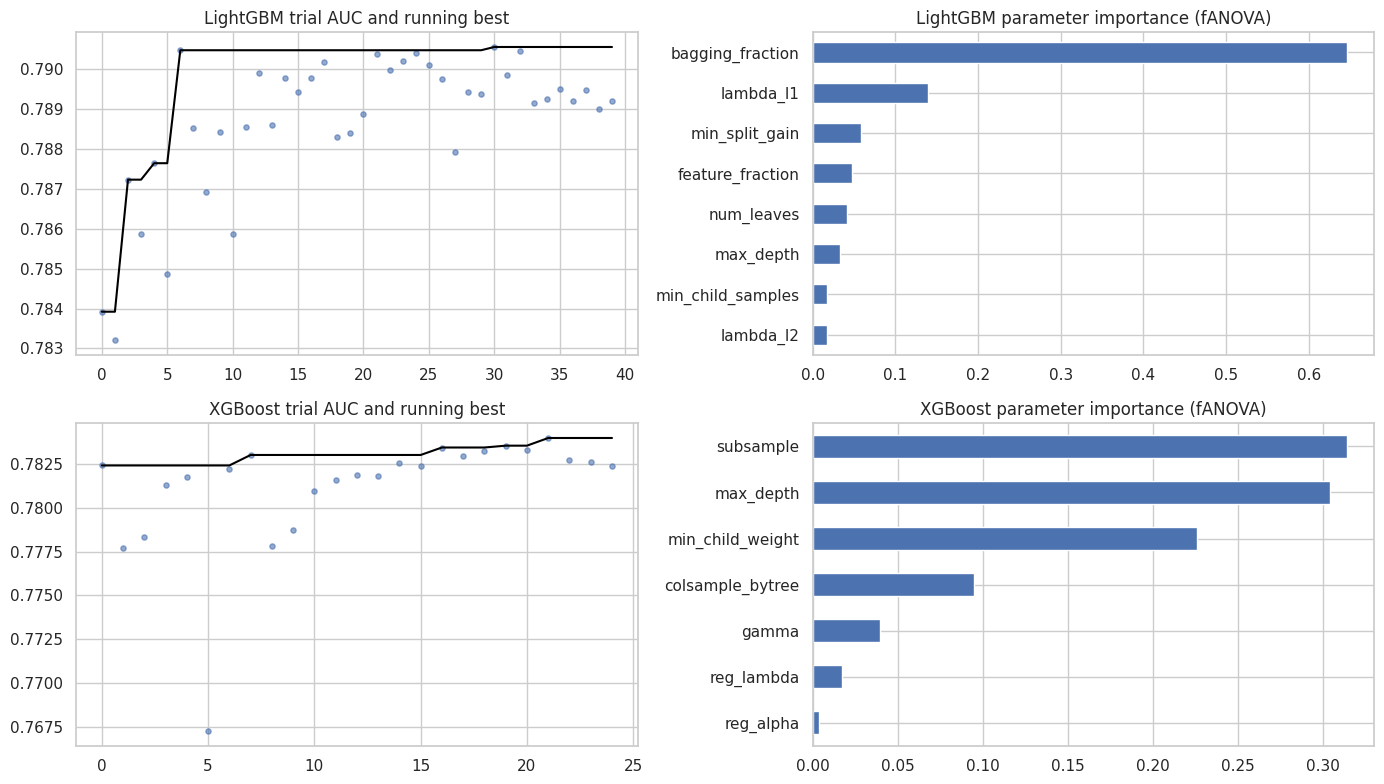

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for row, (name, study) in enumerate([("LightGBM", lgb_study), ("XGBoost", xgb_study)]):
    values = np.array([t.value for t in study.trials if t.value is not None])
    axes[row, 0].scatter(range(len(values)), values, s=14, alpha=0.6)
    axes[row, 0].plot(np.maximum.accumulate(values), color="black")
    axes[row, 0].set_title(f"{name} trial AUC and running best")
    importance = pd.Series(get_param_importances(study, evaluator=FanovaImportanceEvaluator(seed=SEED)))
    print(f"\n{name} parameter importance\n{importance.round(3).to_string()}")
    importance.iloc[::-1].plot.barh(ax=axes[row, 1])
    axes[row, 1].set_title(f"{name} parameter importance (fANOVA)")
fig.tight_layout()
save(fig, "01_tuning")

**Conclusion.** Both searches flattened out well before their budgets ran out. LightGBM found 0.7905 at trial 6 and improved by only 0.0001 in the next 33 trials, and XGBoost gained 0.001 over its last 15 trials, so more trials would likely add little. fANOVA attributes most of LightGBM's variation to the row sampling fraction (0.65) and L1 regularisation (0.14). For XGBoost, row subsampling (0.32), tree depth (0.30) and minimum child weight (0.23) matter most.

## Write the outputs

Aim: save the selected features, the full tuned parameter sets (learning rate excluded, notebook 4 sets it), the baseline scores and the trial histories.

In [8]:
best = {
    "lgbm": {**BASE_LGB, **lgb_study.best_params, "bagging_freq": 1},
    "xgb": {**BASE_XGB, **xgb_study.best_params},
    "lgbm_tuning_auc": lgb_study.best_value,
    "xgb_tuning_auc": xgb_study.best_value,
    "lgbm_tuning_rounds": lgb_study.best_trial.user_attrs["rounds"],
    "xgb_tuning_rounds": xgb_study.best_trial.user_attrs["rounds"],
}
(OUT / "best_params.json").write_text(json.dumps(best, indent=1))
(OUT / "selected_features.json").write_text(json.dumps({"features": selected, "dropped": dropped}))
(OUT / "baseline_metrics.json").write_text(json.dumps(baseline, indent=1))
lgb_study.trials_dataframe().to_csv(OUT / "optuna_lgbm.csv", index=False)
xgb_study.trials_dataframe().to_csv(OUT / "optuna_xgb.csv", index=False)
print(json.dumps(baseline, indent=1))
print(f"elapsed {elapsed()}")

{
 "logistic_cv_auc": 0.777757516051724,
 "logistic_cv_std": 0.0012685451639652982,
 "lgbm_default_cv_auc": 0.7866464563696512,
 "lgbm_default_cv_std": 0.0009407608349108016,
 "lgbm_default_rounds": 152
}
elapsed 192.4 min


**Conclusion.** The tuned parameter sets, the 723 selected features, both baseline scores and both trial histories are saved. The whole notebook ran in about 3.3 hours on Kaggle's CPU, which is why tuning lives in its own notebook rather than sharing a session with final training.

## Summary

- Baselines: logistic regression 0.7778 and untuned LightGBM 0.7866 (5-fold AUC on training rows only).
- Feature pruning keeps 723 of 836 features; the 113 dropped were never used by any default LightGBM fold model.
- Tuned LightGBM reaches 0.7906 and tuned XGBoost 0.7840 (half sample), both at learning rate 0.1 on 3 folds. Both prefer simple, heavily regularised trees.
- Both searches plateaued early, so the tuned settings are a stable base for notebook 4, which retrains at learning rate 0.02 on 5 folds, blends the two models and makes the only holdout evaluation.